In [1]:
import numpy as np
from qibo import models, gates

from tncdr.evolutors.tensor_network.tensor_network import TensorNetwork
from tncdr.evolutors.tensor_network.w_utils import (
    _compute_all_w_tensors,
    pauli_pauli_expansion,
    basis_pauli_expansion,
    X_pauli_expansion,
    theta_pauli_expansion
)

Ws = _compute_all_w_tensors()

def sample_random_pauli(n:int):
    possible_symbols = list('IXYZ')
    return ''.join([possible_symbols[np.random.randint(len(possible_symbols))] for _ in range(n)])

def pauli_tensors(pauli_string:str):
    for p in pauli_string:
        if 'IXYZ'.find(p) >= 0:
            yield Ws[p]

/home/matteo/Documents/PhD/tncdr/src/tncdr/evolutors/tensor_network/w_utils.py:92: ComplexWarning: Casting complex values to real discards the imaginary part
  return tn.tensornet.nodes['F']['tensor'].astype(float)/4


In [2]:
N=3
    
rotation_pauli = sample_random_pauli(N)
observable = "XXX"
theta =  2*np.pi*np.random.rand()
intial_state = '0' * N

print(f'Rotation generator: {rotation_pauli}')
print(f'H: {observable}')
print(f'rho_0: |{intial_state}X{intial_state}|')
print(f'theta: {theta}, {1-2*np.sin(theta/2)**2}, {2*np.sin(theta/2)*np.cos(theta/2)}')

# Build TensorNetwork
tn = TensorNetwork()

# Add initial state
for n, state in enumerate(intial_state):
    tn.add_tensor(f'T{n}', tensor=basis_pauli_expansion(state))

# Add one rotation
for n, w_tensor in enumerate(pauli_tensors(rotation_pauli)):
    tn.add_tensor(id=f'W{n}', tensor=w_tensor)
    tn.add_edge(f'T{n}', f'W{n}', 'v_link', (0,2))

tn.add_tensor(id='theta', tensor=theta_pauli_expansion(theta=theta))
tn.add_edge('theta', 'W0', 'h_link', (0,1))

for n in range(N-1):
    tn.add_edge(f'W{n}', f'W{n+1}', 'h_link', (0,1))

tn.add_tensor(id='X', tensor=X_pauli_expansion())
tn.add_edge(f'W{N-1}', 'X', 'h_link', (0,0))

# Connect to the observable
for n, o in enumerate(observable):
    tn.add_tensor(f'O{n}', tensor=pauli_pauli_expansion(o))
    tn.add_edge(f'O{n}', f'W{n}', 'v_link', (0,3))

Rotation generator: YXX
H: XXX
rho_0: |000X000|
theta: 6.1914993341295625, 0.9957997847720211, -0.09155757012938044


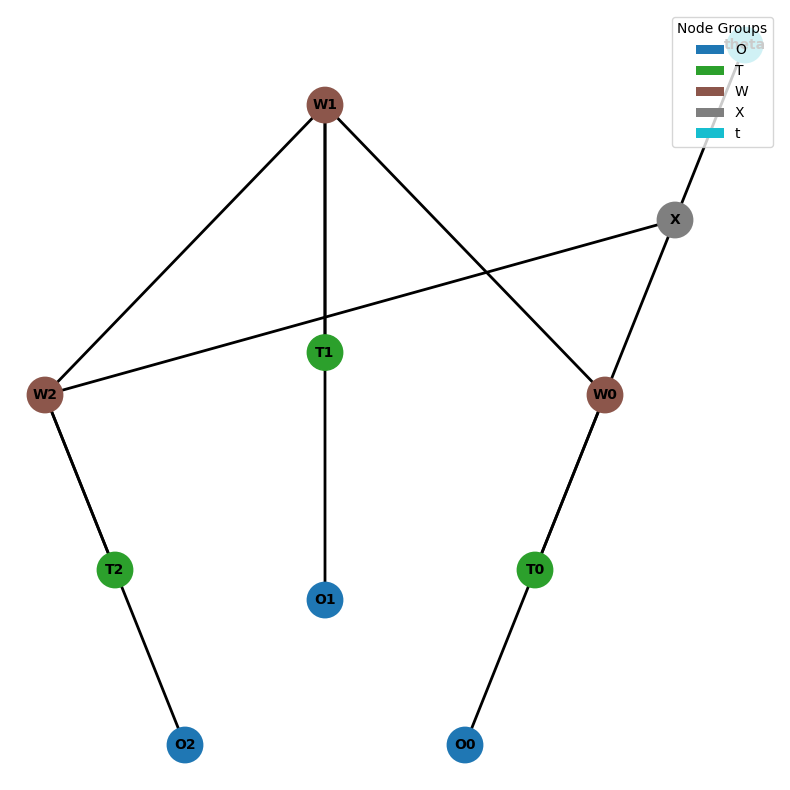

In [3]:
tn.draw()

In [4]:
# Contract the TensorNetwork
tn.contract('theta', 'W0', 'h_link', 'tmp')
for n in range(N-1):
    tn.contract(f'T{n}', 'tmp', 'v_link', 'tmp2')
    tn.contract(f'O{n}', 'tmp2', 'v_link', 'tmp3')
    tn.contract(f'tmp3', f'W{n+1}', 'h_link', 'tmp')

tn.contract(f'T{N-1}', 'tmp', 'v_link', 'tmp2')
tn.contract(f'O{N-1}', 'tmp2', 'v_link', 'tmp3')
tn.contract('tmp3', 'X', 'h_link', 'F')

# Output the result
print(tn.tensornet.nodes['F']['tensor'].item())

0.09155757012938043
